In [1]:
# Imports
from matplotlib.animation import FuncAnimation
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.signal import resample
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import pandas as pd
import numpy as np
import json

In [ ]:
data = pd.read_parquet("../data/cleaned_data.parquet")

In [3]:
# Getting pivot table
pivot_df = pd.read_parquet("../data/pivot.parquet")

In [ ]:
scores_df = pd.read_parquet("./data/pca_results.parquet")

In [ ]:
normalized_df = pd.read_parquet("./data/normalized_pca.parquet")

In [ ]:
# Get frame-wise mean for each PC
pcs = ["PC1", "PC2", "PC3"]
mean_df = normalized_df.groupby("frame_norm")[["PC1", "PC2", "PC3"]].mean().reset_index()
mean_df.rename(columns = {'PC1' : 'PC1_mean', 'PC2' : 'PC2_mean', 'PC3' : 'PC3_mean'}, inplace = True)

# Merge mean with normalized
merged = normalized_df.merge(mean_df, on="frame_norm", how="left")

# Calculate difference between mean pitch and individual pitch for each frame
for pc in pcs:
    merged[f"{pc}_diff"] = merged[pc] - merged[f"{pc}_mean"]

merged.head(2)

In [ ]:
# Find max and min values for each PC
agg = (
    merged
    .groupby(["userID", "sessionID", "pitchNum"], as_index=False)
    .agg(
        PC1_max=("PC1_diff", "max"),
        PC1_min=("PC1_diff", "min"),
        PC2_max=("PC2_diff", "max"),
        PC2_min=("PC2_diff", "min"),
        PC3_max=("PC3_diff", "max"),
        PC3_min=("PC3_diff", "min"),
    )
)
# display(agg)

poi_records = []

# Keep track of which PC/max/min selected each pitch
for pc in [1,2,3]:
    for extreme in ["max", "min"]:
        col = f"PC{pc}_{extreme}"
        row = agg.loc[agg[col].idxmax() if extreme == "max" else agg[col].idxmin()]
        poi = (row["userID"], row["sessionID"], row["pitchNum"])
        desc = f"PC{pc} {extreme}"
        # Check if POI already in records
        existing = next((r for r in poi_records if r["pitch_of_interest"] == poi), None)
        if existing:
            existing["description"] += f", {desc}"
        else:
            poi_records.append({"POI": len(poi_records) + 1, "pitch_of_interest": poi, "description": desc})

poi_df = pd.DataFrame(poi_records)
pitches_of_interest = poi_df["pitch_of_interest"]
pitch_of_interest = []
for pitch in pitches_of_interest:
    pitch_of_interest.append(pitch)
display(poi_df)

In [ ]:
# Build a mapping: POI -> list of PCs where it is min/max
poi_to_pcs = {}
for idx, r in enumerate(poi_records):
    # extract PC numbers from description like "PC1 max, PC3 min"
    pcs_for_poi = [d.split()[0] for d in r["description"].split(", ")]
    poi_to_pcs[r["pitch_of_interest"]] = pcs_for_poi

# Assign a color to each POI
poi_colors = cm.tab10.colors[:len(pitch_of_interest)]
poi_to_color = {poi: poi_colors[i] for i, poi in enumerate(pitch_of_interest)}

In [ ]:
from plots import plot_pca, plot_diffs
plot_pca(normalized_df, poi_to_color, poi_to_pcs, pitch_of_interest)
plot_diffs(merged, poi_to_color, poi_to_pcs, poi_records)

In [ ]:
from animations import animate

for i in range(len(pitch_of_interest)):
    print(f"Starting animation {i}")
    uid, sid, pid = pitch_of_interest[i]
    sel = data[
        (data['userID'] == uid) &
        (data['sessionID'] == sid) &
        (data['pitchNum'] == pid)
    ]
    animate(sel, animation_type = 'real')
print("Done Animating")

In [2]:
normalized_raw = pd.read_parquet("./data/normalized_raw.parquet")
normalized_raw.head()

,frame_norm,x_C7,x_CLAV,x_LANK,x_LASI,x_LBHD,x_LELB,x_LFHD,x_LFIN,x_LFRM,...,z_RWRB,z_STRN,z_T10,userID,sessionID,pitchNum,height,weight,pitchType,pitchSpeed
0,0.0,0.003564,0.057339,0.183473,0.217727,-0.001984,0.361450,0.120232,0.257619,0.323177,...,1.153992,1.300240,1.270855,000002,003034,002,73,207,FF,80.9
1,1.0,0.007236,0.058021,0.183709,0.218794,0.001263,0.364117,0.123117,0.255129,0.323549,...,1.155824,1.301268,1.272222,000002,003034,002,73,207,FF,80.9
2,2.0,0.010686,0.058724,0.183614,0.220303,0.004052,0.366343,0.125543,0.252164,0.323490,...,1.158136,1.301872,1.272980,000002,003034,002,73,207,FF,80.9
3,3.0,0.013491,0.059415,0.183507,0.219852,0.006235,0.368358,0.127352,0.248520,0.322893,...,1.160090,1.301934,1.272845,000002,003034,002,73,207,FF,80.9
4,4.0,0.015830,0.059449,0.182800,0.219864,0.008030,0.370265,0.128852,0.243874,0.321657,...,1.162293,1.301564,1.272164,000002,003034,002,73,207,FF,80.9


In [7]:
# Identify all marker columns
motion_cols = [c for c in normalized_raw.columns if c.startswith(("x_", "y_", "z_"))]

# Compute average motion per normalized frame
norm_avg_motion = (
    normalized_raw
    .groupby("frame_norm", as_index=False)[motion_cols]
    .mean()
)
norm_avg_motion = norm_avg_motion.rename(columns={'frame_norm': 'frame'})
norm_avg_motion.head()

,frame,x_C7,x_CLAV,x_LANK,x_LASI,x_LBHD,x_LELB,x_LFHD,x_LFIN,x_LFRM,...,z_RPSI,z_RSHO,z_RTHI,z_RTIB,z_RTOE,z_RUPA,z_RWRA,z_RWRB,z_STRN,z_T10
0,0.0,0.121139,0.135674,0.263402,0.235848,0.109542,0.311626,0.214191,0.184778,0.258807,...,1.083628,1.521187,0.722744,0.370905,0.081325,1.378343,1.264104,1.224652,1.281410,1.227316
1,1.0,0.121008,0.134245,0.263071,0.235443,0.108922,0.310584,0.213267,0.181986,0.256963,...,1.083099,1.521042,0.722403,0.370947,0.081509,1.378421,1.265109,1.225861,1.281298,1.226876
2,2.0,0.120803,0.132642,0.262872,0.234931,0.108188,0.309330,0.212215,0.178927,0.254891,...,1.082536,1.520970,0.722027,0.370944,0.081568,1.378555,1.266449,1.227485,1.281291,1.226423
3,3.0,0.120466,0.130913,0.262858,0.234173,0.107350,0.307832,0.211045,0.175653,0.252621,...,1.081974,1.520951,0.721720,0.370978,0.081819,1.378755,1.268153,1.229537,1.281352,1.226005
4,4.0,0.120084,0.129050,0.263025,0.233314,0.106418,0.306131,0.209804,0.172140,0.250133,...,1.081422,1.521010,0.721614,0.371215,0.082153,1.379044,1.270218,1.232040,1.281486,1.225653


In [6]:
marker_cols = [c for c in pivot_df.columns if c.startswith(("x_", "y_", "z_"))]

raw_avg_motion = (
    pivot_df.reset_index()
    .groupby("frame", as_index=False)[marker_cols]
    .mean()
)
raw_avg_motion.head()

,frame,x_C7,x_CLAV,x_LANK,x_LASI,x_LBHD,x_LELB,x_LFHD,x_LFIN,x_LFRM,...,z_RPSI,z_RSHO,z_RTHI,z_RTIB,z_RTOE,z_RUPA,z_RWRA,z_RWRB,z_STRN,z_T10
0,0,0.121139,0.135674,0.263402,0.235848,0.109542,0.311626,0.214191,0.184778,0.258807,...,1.083628,1.521187,0.722744,0.370905,0.081325,1.378343,1.264104,1.224652,1.281410,1.227316
1,1,0.121146,0.135461,0.263302,0.235815,0.109452,0.311465,0.214058,0.184327,0.258524,...,1.083535,1.521156,0.722710,0.370949,0.081374,1.378352,1.264261,1.224849,1.281380,1.227243
2,2,0.121141,0.135198,0.263212,0.235761,0.109338,0.311269,0.213891,0.183804,0.258182,...,1.083431,1.521121,0.722669,0.370996,0.081440,1.378363,1.264451,1.225080,1.281356,1.227161
3,3,0.121128,0.134986,0.263117,0.235719,0.109254,0.311111,0.213753,0.183379,0.257892,...,1.083343,1.521089,0.722649,0.371059,0.081528,1.378371,1.264623,1.225274,1.281321,1.227096
4,4,0.121113,0.134722,0.263045,0.235645,0.109142,0.310904,0.213580,0.182849,0.257535,...,1.083234,1.521054,0.722601,0.371104,0.081602,1.378388,1.264824,1.225512,1.281299,1.227010


In [10]:
# Identify all columns
motion_cols = [c for c in raw_avg_motion.columns if c != 'frame']

# Melt x, y, z separately
x_cols = [c for c in raw_avg_motion.columns if c.startswith('x_')]
y_cols = [c for c in raw_avg_motion.columns if c.startswith('y_')]
z_cols = [c for c in raw_avg_motion.columns if c.startswith('z_')]

# Melt function
def melt_motion(df, x_cols, y_cols, z_cols):
    # Melt x
    df_x = df.melt(id_vars='frame', value_vars=x_cols, var_name='coord', value_name='x')
    df_x['markerID'] = df_x['coord'].str[2:]  # remove 'x_' prefix
    df_x = df_x.drop(columns='coord')

    # Melt y
    df_y = df.melt(id_vars='frame', value_vars=y_cols, var_name='coord', value_name='y')
    df_y['markerID'] = df_y['coord'].str[2:]
    df_y = df_y.drop(columns='coord')

    # Melt z
    df_z = df.melt(id_vars='frame', value_vars=z_cols, var_name='coord', value_name='z')
    df_z['markerID'] = df_z['coord'].str[2:]
    df_z = df_z.drop(columns='coord')

    # Merge x, y, z on frame and markerID
    df_long = df_x.merge(df_y, on=['frame','markerID']).merge(df_z, on=['frame','markerID'])
    return df_long

# Convert
long_motion = melt_motion(raw_avg_motion, x_cols, y_cols, z_cols)

# Inspect
long_motion.head()

,frame,x,markerID,y,z
0,0,0.121139,C7,0.000000,1.555871
1,1,0.121146,C7,-0.000047,1.555808
2,2,0.121141,C7,-0.000096,1.555739
3,3,0.121128,C7,-0.000133,1.555682
4,4,0.121113,C7,-0.000182,1.555616


In [ ]:
import joblib

pca = joblib.load('./data/pca_model.joblib')
scaler = joblib.load("./data/scaler_model.joblib")

In [ ]:
pca.explained_variance_

In [ ]:
normalized_pca = pd.read_parquet("./data/normalized_pca.parquet")

Saving animation... please wait.
On frame 0 of animation
On frame 0 of animation
On frame 100 of animation
On frame 200 of animation
On frame 300 of animation
On frame 400 of animation
On frame 500 of animation
On frame 600 of animation
On frame 700 of animation
On frame 800 of animation
On frame 900 of animation
On frame 1000 of animation
On frame 1100 of animation
Animation saved as raw_average_motion.mp4


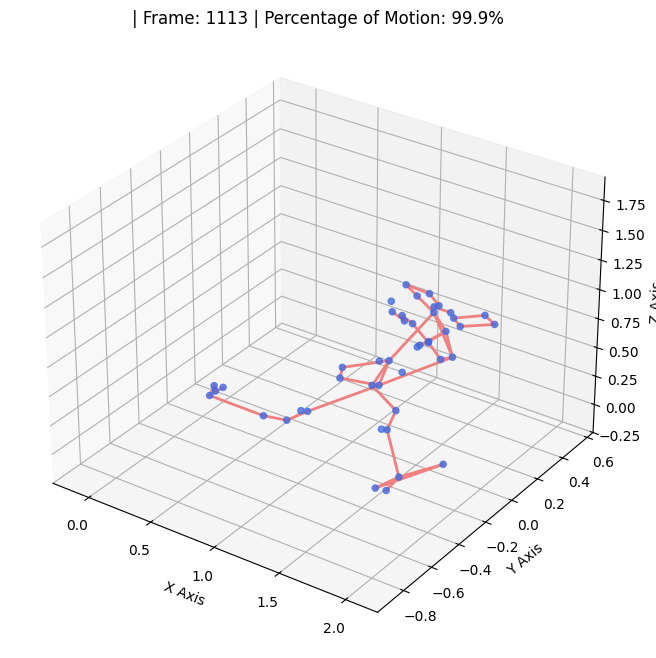

In [11]:
from animations import animate
animate(long_motion, 'theoretical', 'raw_average_motion')

In [ ]:
data.head()